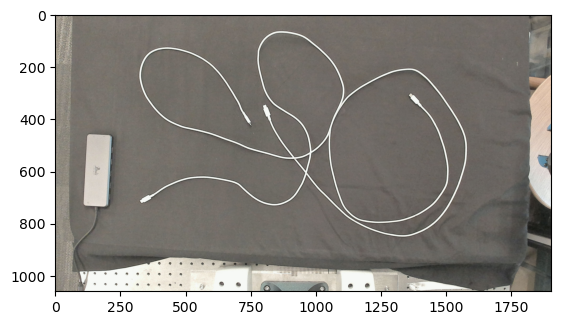

In [1]:
from decluttering.scripts.brio.brio_sensor import BRIOSensor
import numpy as np
import cv2
import matplotlib.pyplot as plt

cam = BRIOSensor(0)
dim = (1060, 1904, 3)
img = cam.read()
img = cv2.resize(img, (img.shape[1]//2, img.shape[0]//2)) # dim

plt.imshow(img)

In [2]:
from decluttering.data.utils.endpoint_detector_dataloader import EndpointDataloader

endpoint_model = EndpointDataloader()
endpoints = endpoint_model.predict(img)['endpoints']


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride
/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [3]:
from decluttering.src.divergence_utils.divergence import get_all_div_points
import time

start_time = time.time()
div_points, trace_1, trace_2 = get_all_div_points(img, endpoints)
print(f'elapsed time: {time.time()-start_time}')

Autoregressive Tracer Using GPU
Autoregressive Tracer Using GPU
Elapsed time for centering pixels on cable: 0.008711576461791992
Elapsed time for simple uncertain trace single tracing: 0.11933732032775879
Time taken for analytic tracer: 0.1281745433807373
Beginning trace with 4 start points
Elapsed time for tracing:  1.8762521743774414
Elapsed time for centering pixels on cable: 0.00957798957824707
Elapsed time for simple uncertain trace single tracing: 0.1192166805267334
Time taken for analytic tracer: 0.12885642051696777
Beginning trace with 4 start points
Elapsed time for tracing:  2.091238260269165
Elapsed time for centering pixels on cable: 0.010489940643310547
Elapsed time for simple uncertain trace single tracing: 0.13286566734313965
Time taken for analytic tracer: 0.14346694946289062
Beginning trace with 4 start points
Elapsed time for tracing:  1.727064847946167
Elapsed time for centering pixels on cable: 0.010692358016967773
Elapsed time for simple uncertain trace single trac

In [10]:
div_points

array([[1089,  361],
       [1054,  451],
       [1053,  453],
       [1053,  454],
       [ 918,  550],
       [ 919,  551],
       [ 963,  601],
       [ 965,  608]], dtype=int32)

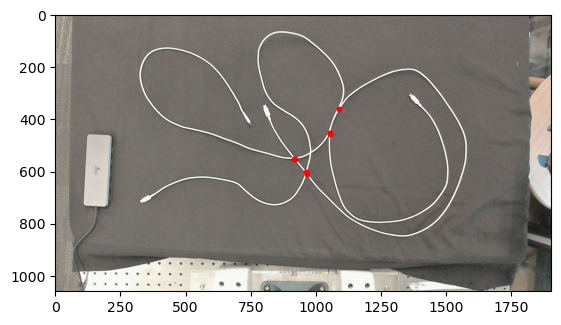

In [12]:
plt.imshow(img)
plt.scatter(div_points[:, 0], div_points[:, 1], c='r', s=10)

In [4]:
from collections import OrderedDict

def visualize_trace_solid_color(img, path, black=False, color=None):
    img = img.copy()
    for i in range(len(path) - 1):        
        # if path is ordered dict, use below logic
        if not isinstance(path, OrderedDict):
            pt1 = tuple(path[i].astype(int))
            pt2 = tuple(path[i+1].astype(int))
        else:
            path_keys = list(path.keys())
            pt1 = path_keys[i]
            pt2 = path_keys[i + 1]
        # print(color_for_pct(i/len(path)))

        cv2.line(img, pt1[::-1], pt2[::-1], color, 2 if not black else 5)
    return img

In [5]:
from skimage.morphology import skeletonize

def isolated_comb_binary_skeleton(colored_mask):
    grayscale = cv2.cvtColor(colored_mask, cv2.COLOR_RGB2GRAY)
    
    _, layered_thresh = cv2.threshold(grayscale, 100, 255, cv2.THRESH_TOZERO_INV)    # 100 hardcoded
    skel_img = skeletonize(layered_thresh, method = "lee")

    # convert to binary image
    bin_img = skel_img // 28   # 28 hardcoded
    
    return bin_img

In [6]:
from scipy.ndimage import convolve

def find_points_of_interest(bin_skel):
    kernel = np.array([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]])

    neighbor_sum = convolve(bin_skel, kernel, mode='constant')

    # if 1 in center of 3x3, sums up all neighbors including center pixel, for each pixel on image
    middle_ones_neighbor_sum = np.multiply(neighbor_sum, bin_skel) 

    points_of_interest = np.flip(np.argwhere(middle_ones_neighbor_sum == 2), axis = 1)

    return points_of_interest

In [7]:
def div_points_from_mask(pts_of_interest, endpts):

    divergence_pts = np.empty([0, 2])

    for poi in pts_of_interest:
        close_to_endpt = False
        for glob_endpt in np.flip(endpts, axis = 1):
            if np.linalg.norm(glob_endpt - poi) <= 20:
                close_to_endpt = True
        if not close_to_endpt:
            divergence_pts = np.append(divergence_pts, np.array([poi]), axis=0)
    
    return divergence_pts

In [8]:
endpoint_model = EndpointDataloader()
endpoints = endpoint_model.predict(img)['endpoints']


def divergence_points_viz(ep_idx_1, ep_idx_2, trace_list):
    CYAN_COLOR = (52, 205, 235)
    MAGENTA_COLOR = (235, 52, 177)

    div_points = np.empty([0, 2])

    trace_1, trace_2 = trace_list[0], trace_list[1]

    mask_1 = visualize_trace_solid_color(np.zeros(img.shape, dtype=np.uint8), trace_1, color = CYAN_COLOR, black = True)
    mask_2 = visualize_trace_solid_color(np.zeros(img.shape, dtype=np.uint8), trace_2, color = MAGENTA_COLOR, black = True)
    layered_mask = mask_2
    bin_skel_img = isolated_comb_binary_skeleton(layered_mask)
    points_of_interest = find_points_of_interest(bin_skel_img)
    div_points_from_mask_list = np.array(div_points_from_mask(points_of_interest, endpoints))
    plt.imshow(layered_mask)
    plt.scatter(div_points_from_mask_list.T[0], div_points_from_mask_list.T[1])
    plt.show()

    div_points = np.append(div_points, div_points_from_mask_list, axis=0)
        
    return div_points

In [9]:
divergence_points_viz(ep_idx_1, end_idx, trace_list)

NameError: name 'ep_idx_1' is not defined

In [ ]:
[0,-1]
[1,-1]